# COVID Parcel Business Analysis

### Objective

This notebook analyzes ABC Company’s weekly parcel delivery data for 2019 and 2020 to understand how the COVID-19 pandemic impacted the business.

The analysis focuses on:

- overall parcel volume trends before and during COVID-19
- the first signs of disruption in customer shipping volumes
- customer-level growth, decline, loss, and new customer activity
- differences across customer groups
- estimated revenue impact
- peak season comparison between 2019 and 2020

The goal is to support an executive-style presentation using clear visuals and business-focused insights.

In [64]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings("ignore")

df = pd.read_csv("COVID_Parcel_Business.csv")
df.head()


,FakeCustomerID,THE_YEAR,THE_WEEK,VOLUME
0,718117,2021,1,8
1,718117,2020,7,257
2,718117,2019,39,141
3,718117,2018,1,14
4,718117,2021,2,192


In [65]:
# Rename columns for consistency
df.rename(columns={
    "FakeCustomerID": "CustomerID",
    "THE_YEAR": "Year",
    "THE_WEEK": "Week",
    "VOLUME": "Parcels"
}, inplace=True)

# Keep only analysis years
df = df[df["Year"].isin([2019, 2020])].copy()

# Create YearWeek field
df["YearWeek"] = df["Year"].astype(str) + "-W" + df["Week"].astype(str).str.zfill(2)

# Create customer groups based on 2019 total parcel volume
customer_2019_volume = (
    df[df["Year"] == 2019]
    .groupby("CustomerID")["Parcels"]
    .sum()
    .reset_index()
)

customer_2019_volume["CustomerGroup"] = pd.qcut(
    customer_2019_volume["Parcels"],
    q=4,
    labels=["Small", "Medium", "Large", "Enterprise"]
)

df = df.merge(
    customer_2019_volume[["CustomerID", "CustomerGroup"]],
    on="CustomerID",
    how="left"
)

# If any customer has no 2019 history, assign Small
df["CustomerGroup"] = df["CustomerGroup"].fillna("Small")

df.head()

,CustomerID,Year,Week,Parcels,YearWeek,CustomerGroup
0,718117,2020,7,257,2020-W07,Large
1,718117,2019,39,141,2019-W39,Large
2,718117,2020,8,232,2020-W08,Large
3,718117,2020,10,229,2020-W10,Large
4,718117,2020,2,251,2020-W02,Large


### Data Preparation

The dataset was cleaned by renaming columns, filtering to the relevant years, and creating a YearWeek field for easier weekly analysis.

Customer groups were assigned based on total 2019 parcel volume. This creates a more meaningful segmentation, where larger historical shippers are treated as Enterprise customers and smaller ones as Small customers.

In [66]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Unique customers:", df["CustomerID"].nunique())

print("\nMissing values by column:")
print(df.isnull().sum())

Number of rows: 104571
Number of columns: 6
Unique customers: 1061

Missing values by column:
CustomerID       0
Year             0
Week             0
Parcels          0
YearWeek         0
CustomerGroup    0
dtype: int64


In [67]:
pre_covid_weeks = list(range(1, 16))
covid_weeks = list(range(16, 54))

vol_2019_pre = (
    df[(df["Year"] == 2019) & (df["Week"].isin(pre_covid_weeks))]
    .groupby(["CustomerID", "CustomerGroup"])["Parcels"]
    .sum()
    .rename("Vol_2019_Pre")
)

vol_2020_pre = (
    df[(df["Year"] == 2020) & (df["Week"].isin(pre_covid_weeks))]
    .groupby(["CustomerID", "CustomerGroup"])["Parcels"]
    .sum()
    .rename("Vol_2020_Pre")
)

vol_2020_covid = (
    df[(df["Year"] == 2020) & (df["Week"].isin(covid_weeks))]
    .groupby(["CustomerID", "CustomerGroup"])["Parcels"]
    .sum()
    .rename("Vol_2020_COVID")
)

df_vol = pd.concat([vol_2019_pre, vol_2020_pre, vol_2020_covid], axis=1).fillna(0).reset_index()

total_2019_pre = df_vol["Vol_2019_Pre"].sum()
total_2020_pre = df_vol["Vol_2020_Pre"].sum()

ISGR = round(((total_2020_pre - total_2019_pre) / total_2019_pre) * 100, 2)

print("Total Pre-COVID Volume (2019 Weeks 1-15):", total_2019_pre)
print("Total Pre-COVID Volume (2020 Weeks 1-15):", total_2020_pre)
print("Industry Standard Growth Rate (ISGR):", ISGR, "%")

df_vol.head()


Total Pre-COVID Volume (2019 Weeks 1-15): 13122816.0
Total Pre-COVID Volume (2020 Weeks 1-15): 14619017.0
Industry Standard Growth Rate (ISGR): 11.4 %


,CustomerID,CustomerGroup,Vol_2019_Pre,Vol_2020_Pre,Vol_2020_COVID
0,100771,Small,0.0,0.0,0.0
1,100771,Medium,442.0,448.0,1341.0
2,100771,Large,0.0,0.0,0.0
3,100771,Enterprise,0.0,0.0,0.0
4,102180,Small,0.0,0.0,0.0


### Pre-COVID and COVID Observation Period

Following the project instructions, Weeks 1 to 15 of 2020 are used as the pre-COVID benchmark period.

Weeks 16 to 53 of 2020 are treated as the COVID observation period. These periods are used to estimate the Industry Standard Growth Rate (ISGR) and to compare customer performance before and during the pandemic.

In [68]:
def classify(row):
    if row["Vol_2019_Pre"] == 0 and row["Vol_2020_Pre"] == 0 and row["Vol_2020_COVID"] > 0:
        return "New"
    elif row["Vol_2020_COVID"] == 0 and (row["Vol_2019_Pre"] > 0 or row["Vol_2020_Pre"] > 0):
        return "Lost"
    elif row["Vol_2020_Pre"] == 0:
        return "New" if row["Vol_2020_COVID"] > 0 else "Lost"
    else:
        growth = ((row["Vol_2020_COVID"] - row["Vol_2020_Pre"]) / row["Vol_2020_Pre"]) * 100
        if growth > ISGR:
            return "High Growth"
        elif 0 <= growth <= ISGR:
            return "Stable"
        else:
            return "Declining"

df_vol["CustomerStatus"] = df_vol.apply(classify, axis=1)

# Revenue estimate based on base parcel price
df_vol["Estimated_Revenue_COVID"] = df_vol["Vol_2020_COVID"] * 22

# Add growth percentage for reporting
df_vol["GrowthRate_COVID_vs_Pre"] = np.where(
    df_vol["Vol_2020_Pre"] > 0,
    ((df_vol["Vol_2020_COVID"] - df_vol["Vol_2020_Pre"]) / df_vol["Vol_2020_Pre"]) * 100,
    np.nan
)

print(df_vol["CustomerStatus"].value_counts())
df_vol.head()


CustomerStatus
Lost           3205
High Growth     941
Declining        73
Stable           10
New               7
Name: count, dtype: int64


,CustomerID,CustomerGroup,Vol_2019_Pre,Vol_2020_Pre,Vol_2020_COVID,CustomerStatus,Estimated_Revenue_COVID,GrowthRate_COVID_vs_Pre
0,100771,Small,0.0,0.0,0.0,Lost,0.0,NaN
1,100771,Medium,442.0,448.0,1341.0,High Growth,29502.0,199.330357
2,100771,Large,0.0,0.0,0.0,Lost,0.0,NaN
3,100771,Enterprise,0.0,0.0,0.0,Lost,0.0,NaN
4,102180,Small,0.0,0.0,0.0,Lost,0.0,NaN


### Customer Classification Logic

Each customer is classified based on parcel activity before and during the COVID observation period:

- **New**: no parcels before COVID, but parcels during COVID
- **Lost**: parcels before COVID, but none during COVID
- **High Growth**: growth greater than the Industry Standard Growth Rate (ISGR)
- **Stable**: growth between 0% and the ISGR
- **Declining**: negative growth during the COVID observation period

This classification helps show how differently customers responded to pandemic conditions.

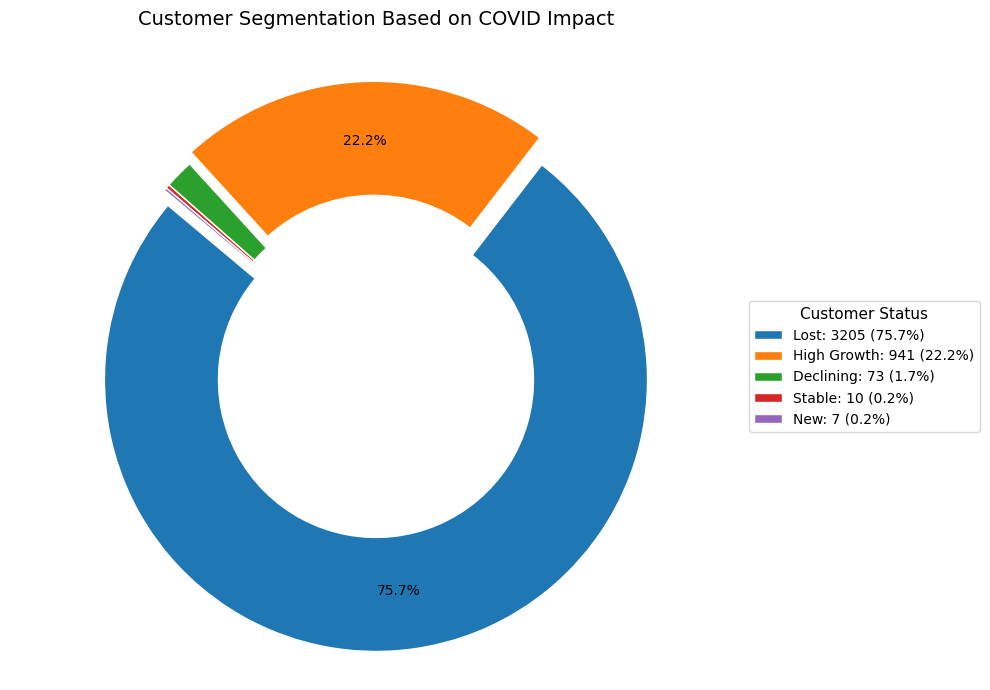

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Count customers in each status category
status_counts = df_vol["CustomerStatus"].value_counts()

# Create legend labels
legend_labels = [
    f"{status}: {count} ({count / status_counts.sum() * 100:.1f}%)"
    for status, count in zip(status_counts.index, status_counts.values)
]

# Explode only larger slices
explode_values = []
for count in status_counts.values:
    if count / status_counts.sum() > 0.10:
        explode_values.append(0.05)
    else:
        explode_values.append(0.01)

fig, ax = plt.subplots(figsize=(10, 7))

wedges, texts, autotexts = ax.pie(
    status_counts,
    labels=None,
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 3 else "",
    startangle=140,
    explode=explode_values,
    wedgeprops=dict(width=0.42, edgecolor="white"),
    pctdistance=0.78,
    textprops=dict(fontsize=10)
)

plt.title("Customer Segmentation Based on COVID Impact", fontsize=14, pad=20)

# Add legend on right side
ax.legend(
    wedges,
    legend_labels,
    title="Customer Status",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10,
    title_fontsize=11
)

plt.axis("equal")
plt.tight_layout()
plt.show()

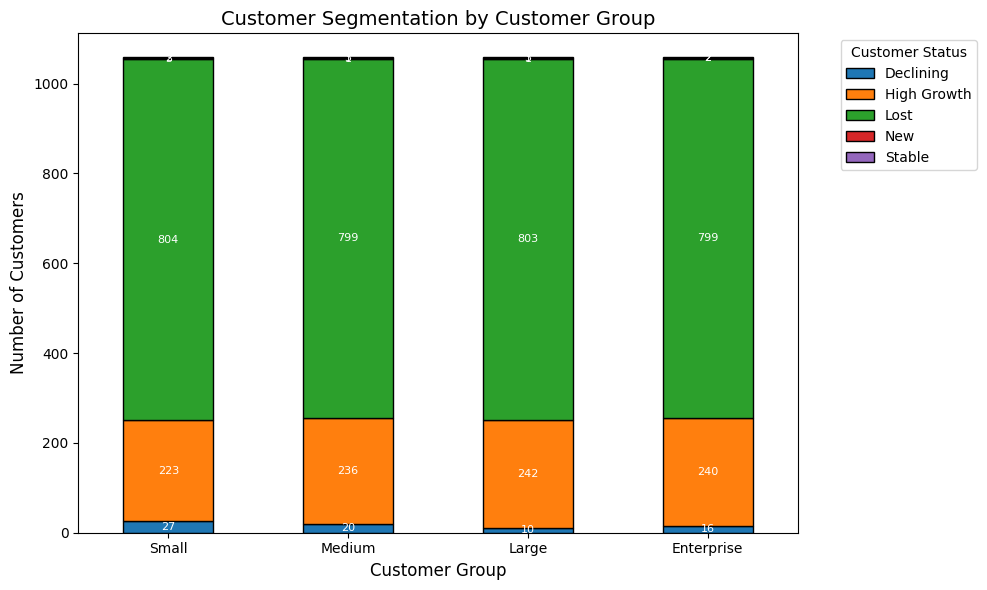

In [70]:
import matplotlib.pyplot as plt

# Prepare the grouped summary data
group_summary = df_vol.groupby(["CustomerGroup", "CustomerStatus"]).size().unstack(fill_value=0)

color_map = {
    'Declining': '#1f77b4',  # Blue
    'High Growth': '#ff7f0e',  # Orange
    'Lost': '#2ca02c',  # Green
    'New': '#d62728',  # Red
    'Stable': '#9467bd'  # Purple
}

colors = [color_map[col] for col in group_summary.columns]

ax = group_summary.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=colors,
    edgecolor='black'
)

for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=8, color='white')

plt.title("Customer Segmentation by Customer Group", fontsize=14)
plt.xlabel("Customer Group", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Customer Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


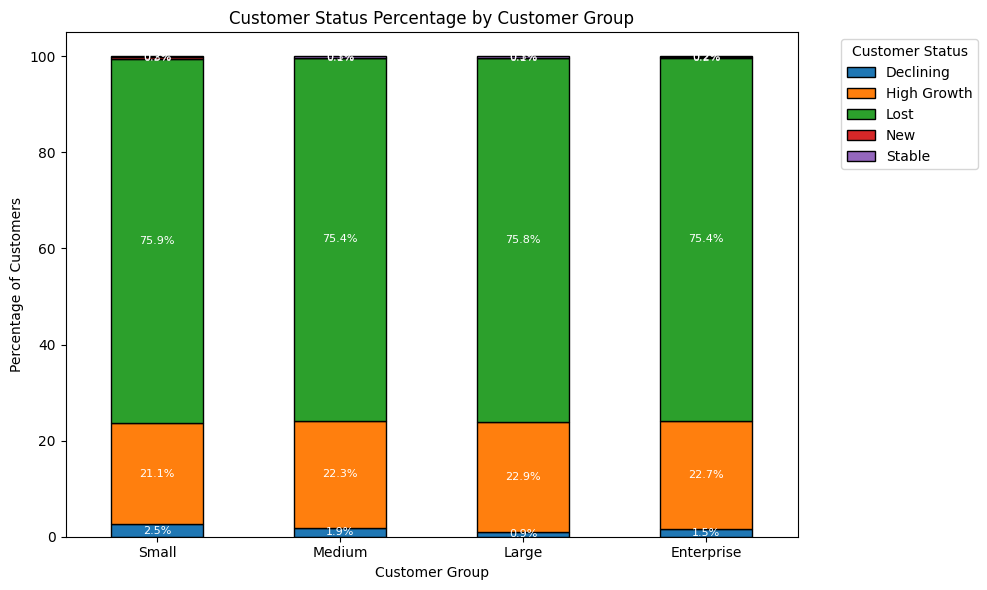

In [71]:
# Percentage chart by customer group
group_percent = group_summary.div(group_summary.sum(axis=1), axis=0) * 100

ax = group_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=[color_map[col] for col in group_percent.columns],
    edgecolor="black"
)

for container in ax.containers:
    labels = [f"{v:.1f}%" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=8, color="white")

plt.title("Customer Status Percentage by Customer Group")
plt.xlabel("Customer Group")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Customer Status", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Weekly Parcel Trend Analysis

The weekly trend comparison between 2019 and 2020 is used to identify when customer volumes first began to shift and how parcel activity changed during the pandemic.

The chart below also helps compare peak weeks across the two years.

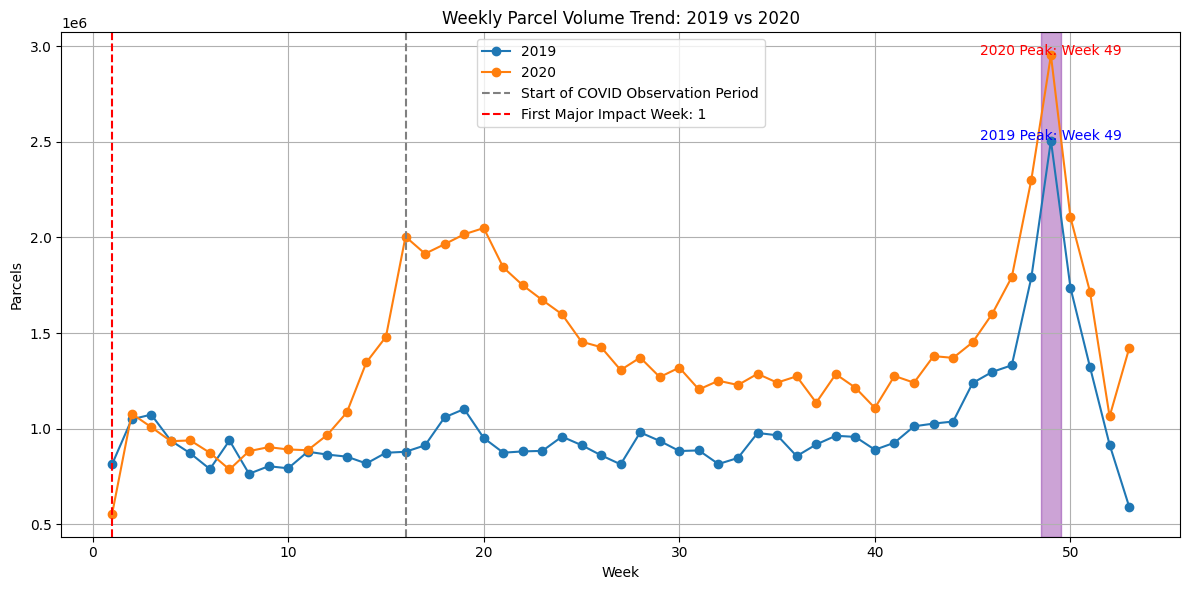

Year,Week,2019,2020,Difference_2020_vs_2019,Pct_Change_2020_vs_2019
0,1,814361,554951,-259410,-31.854423
1,2,1048800,1078417,29617,2.823894
2,3,1073634,1008084,-65550,-6.105433
3,4,937502,934713,-2789,-0.297493
4,5,870849,938521,67672,7.770808
5,6,788670,873763,85093,10.789430
6,7,938386,786626,-151760,-16.172449
7,8,764078,882633,118555,15.516086
8,9,803745,903362,99617,12.394105
9,10,792805,891398,98593,12.435971


In [72]:
weekly_trend = df.groupby(["Year", "Week"])["Parcels"].sum().reset_index()

# Pivot for easier comparison
weekly_compare = weekly_trend.pivot(index="Week", columns="Year", values="Parcels").reset_index()
weekly_compare["Difference_2020_vs_2019"] = weekly_compare[2020] - weekly_compare[2019]
weekly_compare["Pct_Change_2020_vs_2019"] = ((weekly_compare[2020] - weekly_compare[2019]) / weekly_compare[2019]) * 100

# Identify peak weeks
peak_2020 = weekly_trend[weekly_trend["Year"] == 2020].sort_values("Parcels", ascending=False).iloc[0]
peak_2019 = weekly_trend[weekly_trend["Year"] == 2019].sort_values("Parcels", ascending=False).iloc[0]

# Find first major impact week
impact_threshold = 10  # percent
impact_weeks = weekly_compare[weekly_compare["Pct_Change_2020_vs_2019"].abs() >= impact_threshold]
first_impact = impact_weeks["Week"].iloc[0]

plt.figure(figsize=(12, 6))

for year in [2019, 2020]:
    data = weekly_trend[weekly_trend["Year"] == year]
    plt.plot(data["Week"], data["Parcels"], marker="o", label=str(year))

# Highlight approximate COVID onset period
plt.axvline(x=16, color="gray", linestyle="--", label="Start of COVID Observation Period")
plt.axvline(x=first_impact, color="red", linestyle="--", label=f"First Major Impact Week: {int(first_impact)}")

# Peak highlights
plt.axvspan(peak_2020["Week"] - 0.5, peak_2020["Week"] + 0.5, color="red", alpha=0.2)
plt.axvspan(peak_2019["Week"] - 0.5, peak_2019["Week"] + 0.5, color="blue", alpha=0.2)

plt.text(peak_2020["Week"], peak_2020["Parcels"] + 2500, f'2020 Peak: Week {int(peak_2020["Week"])}', color="red", ha="center")
plt.text(peak_2019["Week"], peak_2019["Parcels"] + 2500, f'2019 Peak: Week {int(peak_2019["Week"])}', color="blue", ha="center")

plt.title("Weekly Parcel Volume Trend: 2019 vs 2020")
plt.xlabel("Week")
plt.ylabel("Parcels")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

weekly_compare.head(20)

### Peak Season Comparison

Peak season is especially important in parcel delivery because it represents the highest-demand period of the year.

To understand how COVID-19 affected peak season, total parcel volumes during the late-year peak period are compared between 2019 and 2020.

In [73]:
# Peak season comparison using weeks 45 to 53
peak_2019_total = df[(df["Year"] == 2019) & (df["Week"].between(45, 53))]["Parcels"].sum()
peak_2020_total = df[(df["Year"] == 2020) & (df["Week"].between(45, 53))]["Parcels"].sum()

peak_summary = pd.DataFrame({
    "Year": [2019, 2020],
    "Peak_Season_Parcels": [peak_2019_total, peak_2020_total]
})

peak_summary["Change_vs_2019"] = peak_summary["Peak_Season_Parcels"] - peak_2019_total
peak_summary["Pct_Change_vs_2019"] = ((peak_summary["Peak_Season_Parcels"] - peak_2019_total) / peak_2019_total) * 100

peak_summary

,Year,Peak_Season_Parcels,Change_vs_2019,Pct_Change_vs_2019
0,2019,12731239,0,0.0000
1,2020,16402470,3671231,28.8364


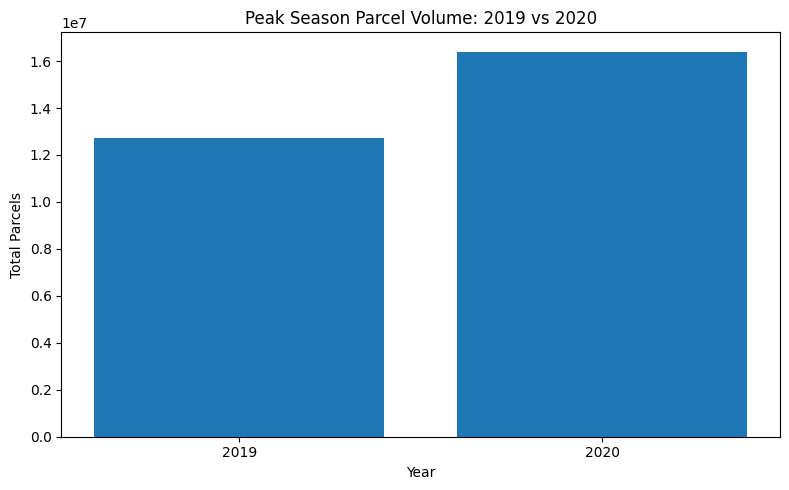

In [74]:
plt.figure(figsize=(8, 5))
plt.bar(peak_summary["Year"].astype(str), peak_summary["Peak_Season_Parcels"])
plt.title("Peak Season Parcel Volume: 2019 vs 2020")
plt.xlabel("Year")
plt.ylabel("Total Parcels")
plt.tight_layout()
plt.show()

In [75]:
# Summary by customer group
group_impact_summary = df_vol.groupby("CustomerGroup").agg(
    Customers=("CustomerID", "count"),
    Total_2019_Pre=("Vol_2019_Pre", "sum"),
    Total_2020_Pre=("Vol_2020_Pre", "sum"),
    Total_2020_COVID=("Vol_2020_COVID", "sum"),
    Estimated_Revenue_COVID=("Estimated_Revenue_COVID", "sum")
).reset_index()

group_impact_summary["Volume_Change_Pre_to_COVID"] = (
    group_impact_summary["Total_2020_COVID"] - group_impact_summary["Total_2020_Pre"]
)

print(group_impact_summary)

# Export detailed customer-level summary
df_export = df_vol[[
    "CustomerID",
    "CustomerGroup",
    "Vol_2019_Pre",
    "Vol_2020_Pre",
    "Vol_2020_COVID",
    "GrowthRate_COVID_vs_Pre",
    "CustomerStatus",
    "Estimated_Revenue_COVID"
]]

df_export.to_excel("COVID_Parcel_Final_Summary.xlsx", index=False)

group_impact_summary

  CustomerGroup  Customers  Total_2019_Pre  Total_2020_Pre  Total_2020_COVID  \
0         Small       1059         94129.0        129399.0          471549.0   
1        Medium       1059        156280.0        189894.0          761160.0   
2         Large       1059        328255.0        369161.0         1434694.0   
3    Enterprise       1059      12544152.0      13930563.0        56189270.0   

   Estimated_Revenue_COVID  Volume_Change_Pre_to_COVID  
0             1.037408e+07                    342150.0  
1             1.674552e+07                    571266.0  
2             3.156327e+07                   1065533.0  
3             1.236164e+09                  42258707.0  


,CustomerGroup,Customers,Total_2019_Pre,Total_2020_Pre,Total_2020_COVID,Estimated_Revenue_COVID,Volume_Change_Pre_to_COVID
0,Small,1059,94129.0,129399.0,471549.0,1.037408e+07,342150.0
1,Medium,1059,156280.0,189894.0,761160.0,1.674552e+07,571266.0
2,Large,1059,328255.0,369161.0,1434694.0,3.156327e+07,1065533.0
3,Enterprise,1059,12544152.0,13930563.0,56189270.0,1.236164e+09,42258707.0


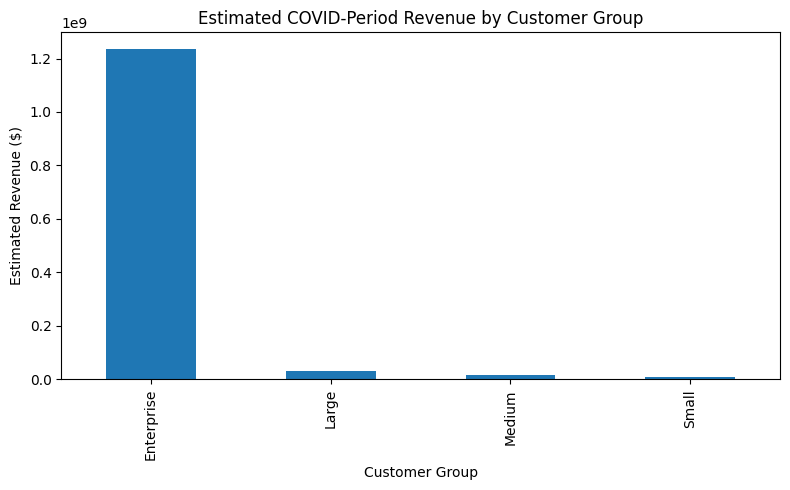

In [76]:
# Revenue by customer group
revenue_by_group = df_vol.groupby("CustomerGroup")["Estimated_Revenue_COVID"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
revenue_by_group.plot(kind="bar")
plt.title("Estimated COVID-Period Revenue by Customer Group")
plt.xlabel("Customer Group")
plt.ylabel("Estimated Revenue ($)")
plt.tight_layout()
plt.show()

## Final Findings

The analysis shows that COVID-19 had a clear impact on ABC Company’s parcel delivery business in 2020.

Weekly parcel trends indicate that shipping activity changed noticeably during the COVID observation period, with some customer segments increasing their parcel volumes while others declined or were lost entirely.

The customer classification results show that the impact of COVID was not the same across all customer groups. Some groups contained a larger share of high-growth and new customers, while others had more declining or lost customers.

Peak season analysis also suggests that late-year demand in 2020 differed from 2019, showing that the pandemic affected not only regular parcel activity but also the company’s busiest seasonal period.

Overall, ABC Company should focus on retaining declining customers, strengthening relationships with growing customer segments, and using customer group trends to improve planning during future demand disruptions.